In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import nltk as nk
import re


In [3]:
df=pd.read_csv('spam.csv',encoding='latin-1')
df.sample

<bound method NDFrame.sample of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

## 1 Dataset Cleaning

In [4]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.rename(columns={'v1':'target','v2':'email_text'},inplace=True)

In [5]:
## labeling the target: Spam=1,ham=0
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

df['target']=encoder.fit_transform(df['target'])

df.sample(10)

,target,email_text
1806,1,Todays Voda numbers ending 1225 are selected t...
1284,0,But if she.s drinkin i'm ok.
2353,1,Please CALL 08712402902 immediately as there i...
3412,0,Where do you need to go to get it?
693,0,Will purchase d stuff today and mail to you. D...
3781,0,How r Ì_ going to send it to me?
688,0,Thanks love. But am i doing torch or bold.
132,0,First answer my question.
5155,0,MY NEW YEARS EVE WAS OK. I WENT TO A PARTY WIT...
4442,0,You know my old Dom I told you about yesterday...


In [6]:
##check for missing and duplicate values 
df.isnull().sum()

target        0
email_text    0
dtype: int64

In [7]:
##check for duplicated rows
df.duplicated().sum()

df=df.drop_duplicates(keep='first')


## 2 Exploratory Data Analysis(EDA)

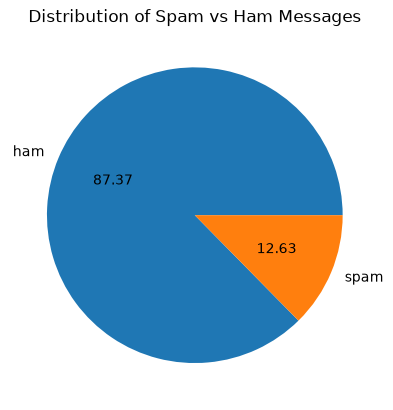

In [8]:
## check for total ham and spam vaues and plot a graph
counts=df['target'].value_counts()
plt.pie(counts,labels=['ham','spam'],autopct='%0.2f')
plt.title('Distribution of Spam vs Ham Messages')
plt.show()

# data is imbalanced

In [9]:
nk.download('punkt')
nk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [10]:
##new column containing charachter lenght of corressponding email text
df['email_text_char_lenght']=df['email_text'].apply(len)

df.head()

,target,email_text,email_text_char_lenght
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [11]:
## tokanize each email into words and save the count in new column
df['email_text_words_len']=df['email_text'].apply(lambda x:len(nk.word_tokenize(x)))

In [12]:
df.head()

,target,email_text,email_text_char_lenght,email_text_words_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [13]:
## Snetence tokanization
df['email_text_sentence_len']=df['email_text'].apply(lambda x:len(nk.sent_tokenize(x)))

df.head(5)

,target,email_text,email_text_char_lenght,email_text_words_len,email_text_sentence_len
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## 3 Data Preprocessing 
 1. Lower Case
 2. Remove Special Characters
 3. Tokenization
 4. Stop word removal
 5. Stemming


In [14]:
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))  # loaded once, lowercase, set for O(1) lookup

def transform_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return ' '.join(stemmed_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
df['transformed_text'] = df['email_text'].apply(transform_text)

In [16]:
pd.set_option('display.max_colwidth', None)
df.loc[2,['email_text','transformed_text']]



email_text          Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
transformed_text                                                        free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over
Name: 2, dtype: str

### WordCloud

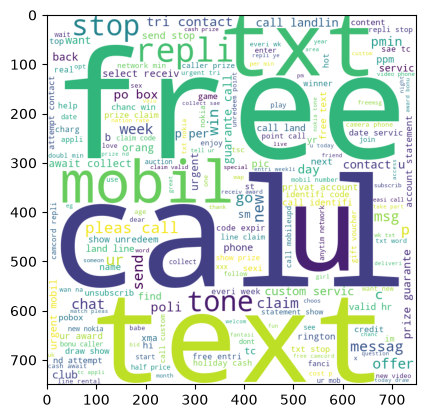

In [17]:
from wordcloud import WordCloud
wc=WordCloud(width=750,height=750,background_color='white',min_font_size=10) 

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

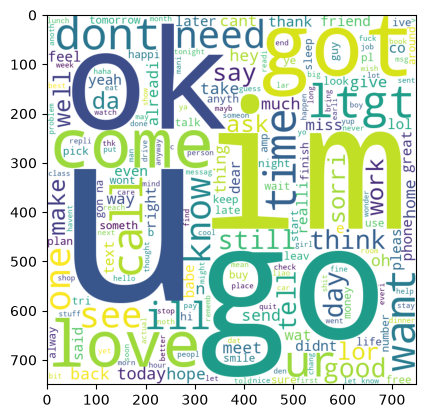

In [18]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

#### Top 50 words in Spam 

In [19]:
spam_corpus=[]
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word) 

In [20]:
len(spam_corpus) ##total words in spam messages

9219

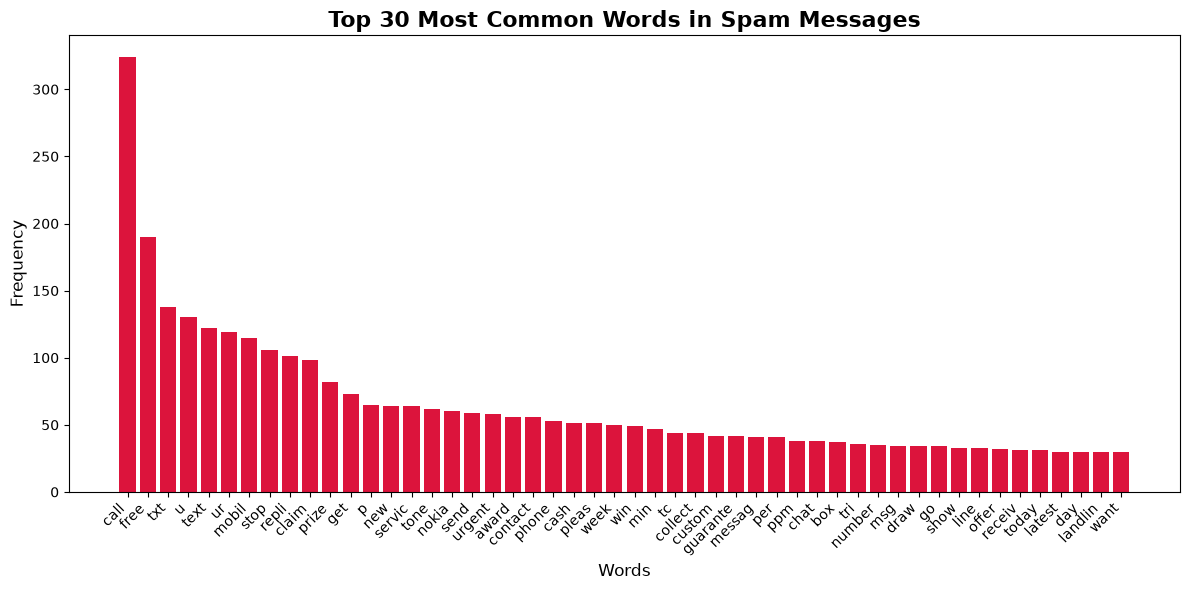

In [21]:
## plot in bar hart for most commont words
from collections import Counter
top_words = Counter(spam_corpus).most_common(50)

df_top = pd.DataFrame(top_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 6))
plt.bar(df_top['Word'], df_top['Count'], color='crimson')

plt.title('Top 30 Most Common Words in Spam Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()                  
plt.show()

### Top 50 in ham msgess 

In [22]:
ham_corpus=[]
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word) 

In [23]:
len(ham_corpus)

36050

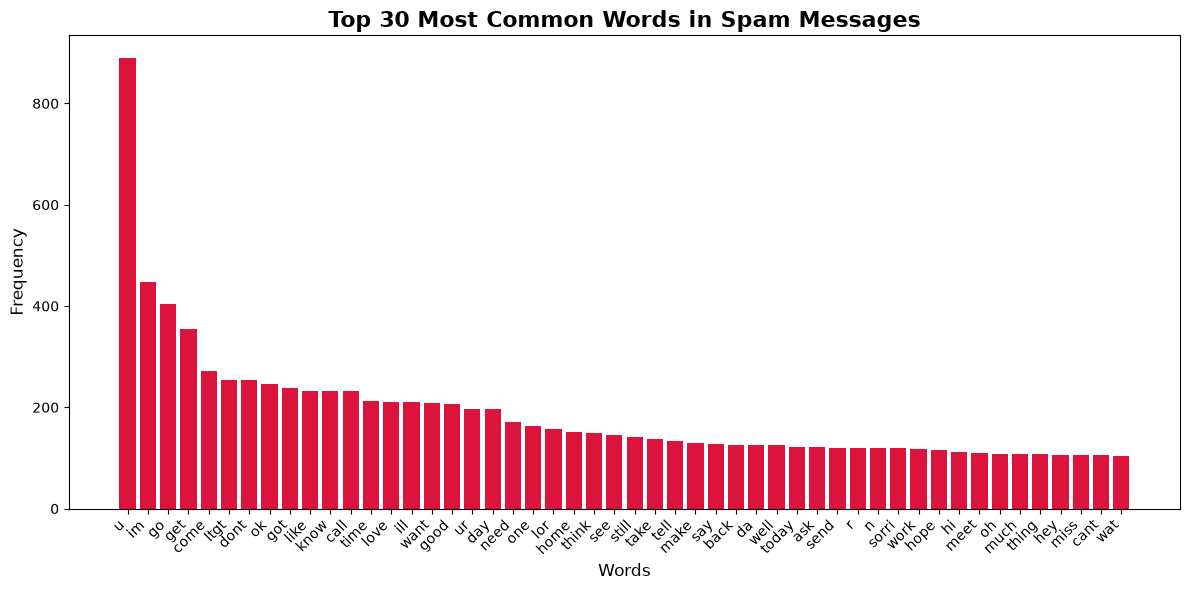

In [24]:
## plot in bar hart for most commont words
from collections import Counter
top_words = Counter(ham_corpus).most_common(50)

df_top = pd.DataFrame(top_words, columns=['Word', 'Count'])
plt.figure(figsize=(12, 6))
plt.bar(df_top['Word'], df_top['Count'], color='crimson')

plt.title('Top 30 Most Common Words in Spam Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()                  
plt.show()

In [26]:
df.head(1)

,target,email_text,email_text_char_lenght,email_text_words_len,email_text_sentence_len,transformed_text
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",111,24,2,go jurong point crazi avail bugi n great world la e buffet cine got amor wat


## Feature Extraction
TF-IDF

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df['transformed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## Model Training

##### we will try two models for taraining to see which one performs better Naive Bayes and ExtraTreesClassifier

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Naive Bayes': MultinomialNB(),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'lr' : LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(f"\n{name}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")


Naive Bayes
  Accuracy  : 0.9710
  Precision : 1.0000
  Recall    : 0.7931
  F1 Score  : 0.8846

Extra Trees
  Accuracy  : 0.9739
  Precision : 0.9836
  Recall    : 0.8276
  F1 Score  : 0.8989

lr
  Accuracy  : 0.9623
  Precision : 0.9492
  Recall    : 0.7724
  F1 Score  : 0.8517


##### 